In [29]:
import os
import random
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras import Model

In [30]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = "2"

In [31]:
BASE_DIR = "/kaggle/input/mstar-dataset-8-classes/Padded_imgs"

INPUT_SHAPE = (224, 224)

EPOCHS = 50

BATCH_SIZE=32

CLASSES = 8

In [32]:
import shutil
shutil.rmtree("Padded_imgs/.ipynb_checkpoints", ignore_errors=True)

In [33]:
def get_categories(root_path) -> None:
    """
        DESCRIPTION
        ___________
        This function prints the number of categories in the dataset.
        
        INPUTS
        ______
        dir_path(str): Path of the root directory.
        
        OUTPUT
        ______
        This function returns None.
    """
    for idx, directory in enumerate(os.listdir(root_path)):
        print(f"Class {idx} is {directory}")

In [34]:
get_categories(root_path="Padded_imgs")

Class 0 is ZIL131
Class 1 is BTR_60
Class 2 is D7
Class 3 is BRDM_2
Class 4 is T62
Class 5 is SLICY
Class 6 is ZSU_23_4
Class 7 is 2S1


In [35]:
def plot_total_images(base_dir):
    """
        DESCRIPTION
        ___________
        This function plots simple barplot on the total number of images present in the dataset.
        
        INPUTS
        ______
        dir_path(str): Path of the root directory.
        
        OUTPUT
        ______
        This function returns None.
        
    """
    data = {"category":[], "images": []}
    for key, value in zip(os.listdir(base_dir), map(lambda directory: len(os.listdir(os.path.join(base_dir, directory))), os.listdir(base_dir))):
        data["category"].append(key)
        data["images"].append(value)
    data = pd.DataFrame(data)
    plt.figure(figsize=(15, 8))
    sns.barplot(x="category", y="images", data=data, palette="mako")

/tmp/ipykernel_87930/102494365.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="category", y="images", data=data, palette="mako")


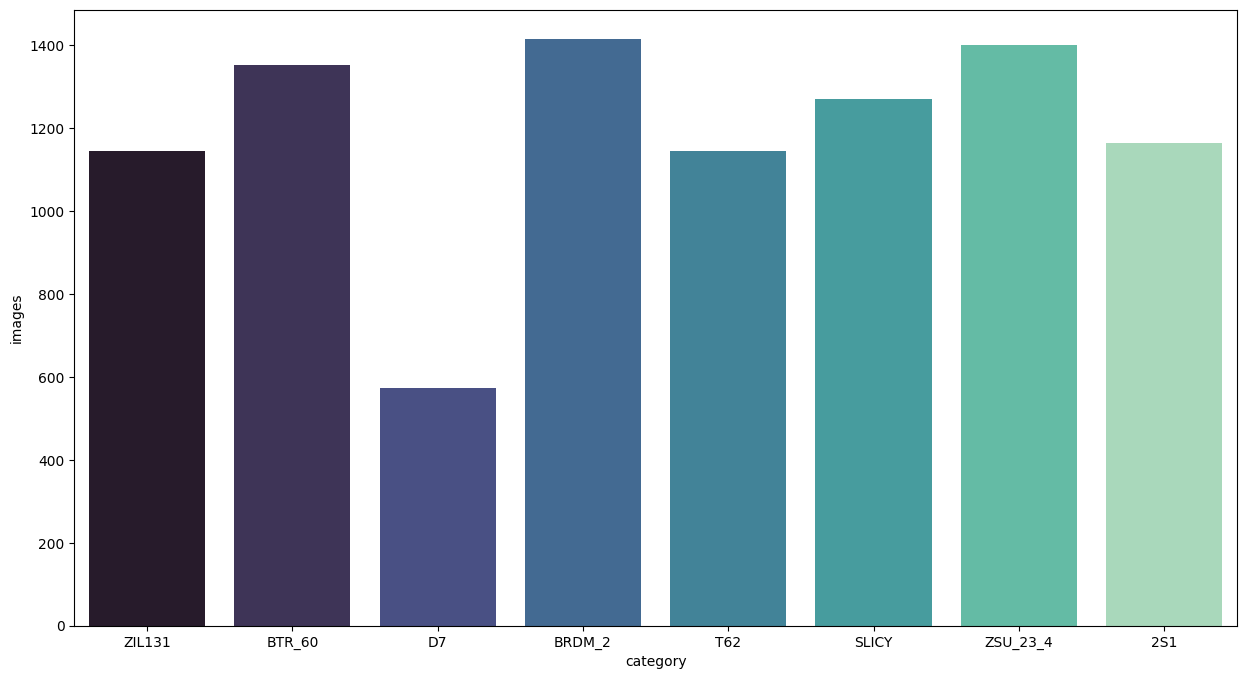

In [36]:
plot_total_images(base_dir="Padded_imgs")

In [37]:
def plot_random_category(dir_path) -> None:
    """
        DESCRIPTION
        ___________
        This fuction plots 5 random images of random category from dataset.
        
        INPUTS
        ______
        dir_path(str): Path of the cats or dogs directory.
        
        OUTPUTS
        _______
        This function returns None
    """
    class_ = random.choice(os.listdir(dir_path))
    fig, axis = plt.subplots(nrows=1, ncols=5, figsize=(20, 6))
    random_images = map(lambda image: os.path.join(f"{dir_path}/{class_}", image), random.sample(os.listdir(os.path.join(dir_path, class_)), k=5))
    plt.suptitle(" ".join(class_.split("_")), fontsize=25)
    for idx, image in enumerate(random_images):
        img = mpimg.imread(image)
        axis[idx].imshow(img)
        axis[idx].axis("off")

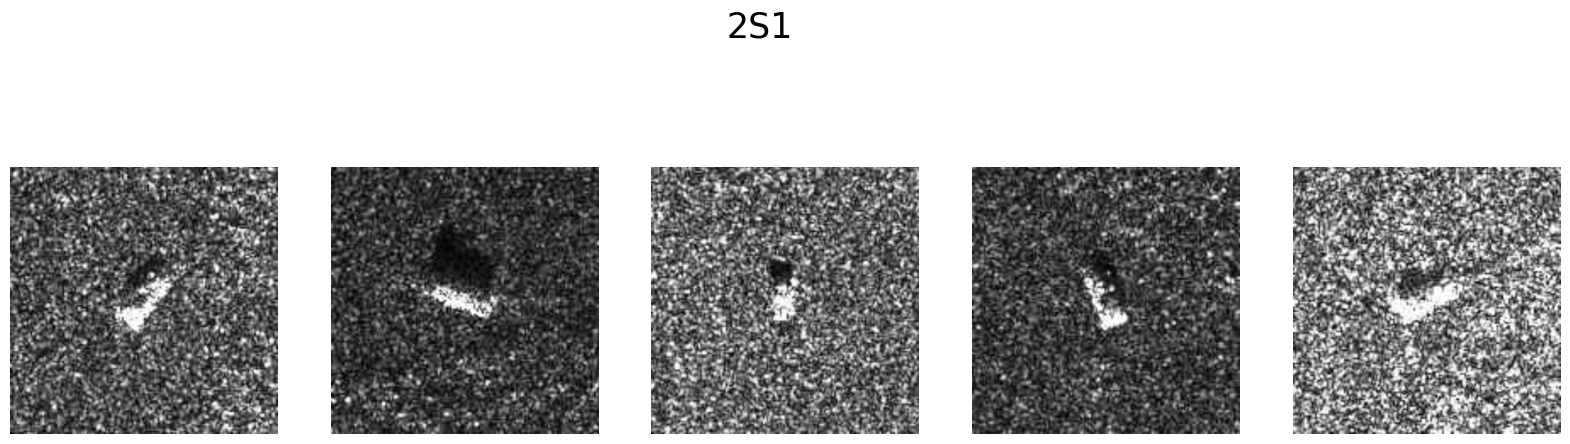

In [38]:
plot_random_category(dir_path="Padded_imgs")

In [39]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
)

In [40]:
BASE_DIR = "Padded_imgs"

In [41]:
train_data = datagen.flow_from_directory(
    directory=BASE_DIR,
    target_size=INPUT_SHAPE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    class_mode="categorical",
    subset="training"
)

test_data = datagen.flow_from_directory(
    directory=BASE_DIR,
    target_size=INPUT_SHAPE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    class_mode="categorical",
    subset="validation"
)

Found 7576 images belonging to 8 classes.
Found 1890 images belonging to 8 classes.


In [42]:
base_model = InceptionV3(
    include_top=False,
    weights="imagenet",
    input_shape=INPUT_SHAPE+(3,)
)

base_model.trainable=False

In [43]:
base_model.summary()

Model: "inception_v3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv2d_94 (Conv2D)          (None, 111, 111, 32)         864       ['input_3[0][0]']             
                                                                                                  
 batch_normalization_94 (Ba  (None, 111, 111, 32)         96        ['conv2d_94[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 activation_94 (Activation)  (None, 111, 111, 32)         0         ['batch_normalizati

In [44]:
inputs = Input(shape=INPUT_SHAPE+(3,))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(units=1000, activation="relu")(x)
x = Dense(units=500, activation="relu")(x)
outputs = Dense(units=CLASSES, activation="softmax")(x)

model = Model(inputs, outputs)

In [45]:
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 inception_v3 (Functional)   (None, 5, 5, 2048)        21802784  
                                                                 
 global_average_pooling2d_1  (None, 2048)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_3 (Dense)             (None, 1000)              2049000   
                                                                 
 dense_4 (Dense)             (None, 500)               500500    
                                                                 
 dense_5 (Dense)             (None, 8)                 4008      
                                                           

In [46]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [47]:
x, y = next(train_data)
print("Generator:", x.shape, y.shape)

print("Model:", model.input_shape)

Generator: (32, 224, 224, 3) (32, 8)
Model: (None, 224, 224, 3)


In [48]:
history = model.fit(
    train_data,
    epochs=EPOCHS,
    steps_per_epoch=len(train_data),
    validation_data=test_data,
    validation_steps=len(test_data)
)

Epoch 1/50


2026-02-20 11:18:49.205666: I external/local_xla/xla/service/service.cc:168] XLA service 0x7eff0f678ee0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-20 11:18:49.205713: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2026-02-20 11:18:49.211571: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1771586329.321384   89108 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


237/237 [==============================] - 17s 59ms/step - loss: 0.5843 - accuracy: 0.7921 - val_loss: 0.3761 - val_accuracy: 0.8714
Epoch 2/50
237/237 [==============================] - 12s 51ms/step - loss: 0.2573 - accuracy: 0.9067 - val_loss: 0.5268 - val_accuracy: 0.8365
Epoch 3/50
237/237 [==============================] - 13s 53ms/step - loss: 0.1933 - accuracy: 0.9312 - val_loss: 0.4673 - val_accuracy: 0.8513
Epoch 4/50
237/237 [==============================] - 11s 48ms/step - loss: 0.1560 - accuracy: 0.9424 - val_loss: 0.3530 - val_accuracy: 0.8899
Epoch 5/50
237/237 [==============================] - 12s 50ms/step - loss: 0.1256 - accuracy: 0.9543 - val_loss: 0.3476 - val_accuracy: 0.9005
Epoch 6/50
237/237 [==============================] - 12s 50ms/step - loss: 0.1035 - accuracy: 0.9644 - val_loss: 0.5037 - val_accuracy: 0.8481
Epoch 7/50
237/237 [==============================] - 11s 48ms/step - loss: 0.0995 - accuracy: 0.9653 - val_loss: 0.3399 - val_accuracy: 0.9032
Epo

In [49]:
loss, accuracy = model.evaluate(test_data)
print(f"Loss of the model is {loss}")
print(f"Accuracy of the model is {accuracy}")

60/60 [==============================] - 2s 37ms/step - loss: 0.3686 - accuracy: 0.9392
Loss of the model is 0.36864206194877625
Accuracy of the model is 0.9391534328460693


In [50]:
def plot_loss_curves(history) -> None:
    """
        DESCRIPTION
        ___________
        This function helps in plotting the loss curves i.e. Training and Testing losses and accuracy of the model
        
        INPUT
        ____
        history(history): Models history as input
        
        OUTPUT
        ______
        This function returns None
    """
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy'] 
    
    epochs = range(len(history.history["loss"]))
    plt.plot(epochs, loss, label='training_loss')
    plt.plot(epochs, val_loss, label='val_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()
    
    plt.figure()
    plt.plot(epochs, accuracy, label='training_accuracy')
    plt.plot(epochs, val_accuracy, label='val_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend()
    plt.show()

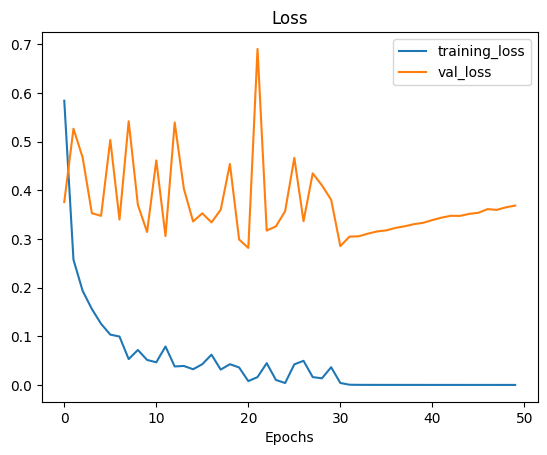

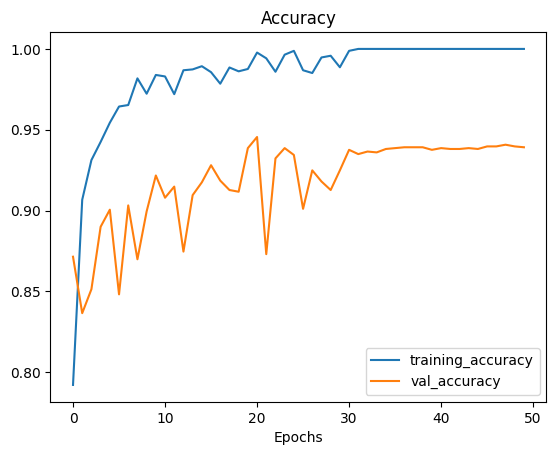

In [51]:
plot_loss_curves(history)